In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Inledning
##### Detta är ett dataset på Premier league säsongen 24/25 från datahub.io/football/english-premier-league. Det innehåller statistik från säsongen, skott, gula kort, gjorda mål, tackling etc. Varje rad är en match som innehåller ett hemmalag, ett bortalag och statistik från matchen. Oklart hur datan samlades in. Datan täcker Premier league 24/25 inte någon annan säsong eller annan liga. 

In [33]:
df = pd.read_csv("season-2425.csv")
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2024-08-16,Man United,Fulham,1,0,H,0,0,D,R Jones,...,5,2,12,10,7,8,2,3,0,0
1,2024-08-17,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,...,2,5,9,18,2,10,3,1,0,0
2,2024-08-17,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,...,6,3,17,14,8,2,2,2,0,0
3,2024-08-17,Everton,Brighton,0,3,A,0,1,A,S Hooper,...,1,5,8,8,1,5,1,1,1,0
4,2024-08-17,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,...,1,4,15,16,3,12,2,4,1,0


In [34]:
df.shape

(380, 22)

##### Datasetet innehåller 380 rader, en per match och 24 kolumner med statistik.

In [35]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      380 non-null    str  
 1   HomeTeam  380 non-null    str  
 2   AwayTeam  380 non-null    str  
 3   FTHG      380 non-null    int64
 4   FTAG      380 non-null    int64
 5   FTR       380 non-null    str  
 6   HTHG      380 non-null    int64
 7   HTAG      380 non-null    int64
 8   HTR       380 non-null    str  
 9   Referee   380 non-null    str  
 10  HS        380 non-null    int64
 11  AS        380 non-null    int64
 12  HST       380 non-null    int64
 13  AST       380 non-null    int64
 14  HF        380 non-null    int64
 15  AF        380 non-null    int64
 16  HC        380 non-null    int64
 17  AC        380 non-null    int64
 18  HY        380 non-null    int64
 19  AY        380 non-null    int64
 20  HR        380 non-null    int64
 21  AR        380 non-null    int64
dtypes: int64(16),

##### Ser datatyper och inget är null. Date behövdes göras om för att kunna läsas som datetime.

In [36]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.513158,1.421053,0.752632,0.610526,13.752632,12.165789,4.834211,4.265789,10.789474,11.276316,5.426316,4.871053,1.905263,2.144737,0.068421,0.068421
std,1.277917,1.189922,0.875867,0.828831,5.588045,5.409987,2.488260,2.341636,3.639840,3.513257,3.183457,3.031358,1.395989,1.430021,0.263030,0.252800
min,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,10.000000,9.000000,3.000000,3.000000,8.000000,9.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,13.000000,11.500000,5.000000,4.000000,11.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,6.000000,13.000000,14.000000,7.000000,7.000000,3.000000,3.000000,0.000000,0.000000
max,7.000000,6.000000,4.000000,5.000000,36.000000,37.000000,16.000000,13.000000,21.000000,21.000000,17.000000,18.000000,7.000000,8.000000,2.000000,1.000000


In [37]:
df.isnull().sum()


Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
Referee     0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

In [38]:
df["Date"] = pd.to_datetime(df["Date"]) #Konvertera till datumobjekt


### Inga saknade värden, Ända tvätten är att konvertera Date från text till datetime för att kunna filtrera på datum

In [39]:
df["HomePoints"] = np.where(df["FTR"] == "H", 3, np.where(df["FTR"] == "D", 1, 0)) #om hemmalaget vann 3 poäng, om oavgjort 1 poäng, annars 0

In [40]:
df["Awaypoints"] = np.where(df["FTR"]  == "A",  3, np.where(df["FTR"] == "D", 1,  0)) #likadan som ovanstående fast för bortalag

In [41]:
first_half = df[df["Date"] < "2025-01-01"] #Filtrerar så jag får datum innan 2025-01-01

In [42]:
home_df = df[["Date", "HomeTeam", "HomePoints"]].rename(columns={"HomeTeam": "Team", "HomePoints": "Points"})

In [43]:
away_df = df[["Date", "AwayTeam", "Awaypoints"]].rename(columns={"AwayTeam": "Team", "Awaypoints": "Points"})

In [44]:
all_matches = pd.concat([home_df, away_df])

In [45]:
all_matches = all_matches.sort_values("Date")
all_matches["CumPoints"] = all_matches.groupby("Team")["Points"].cumsum()

## Vilket lag har legat i toppen längst under säongen, respektive sist? 

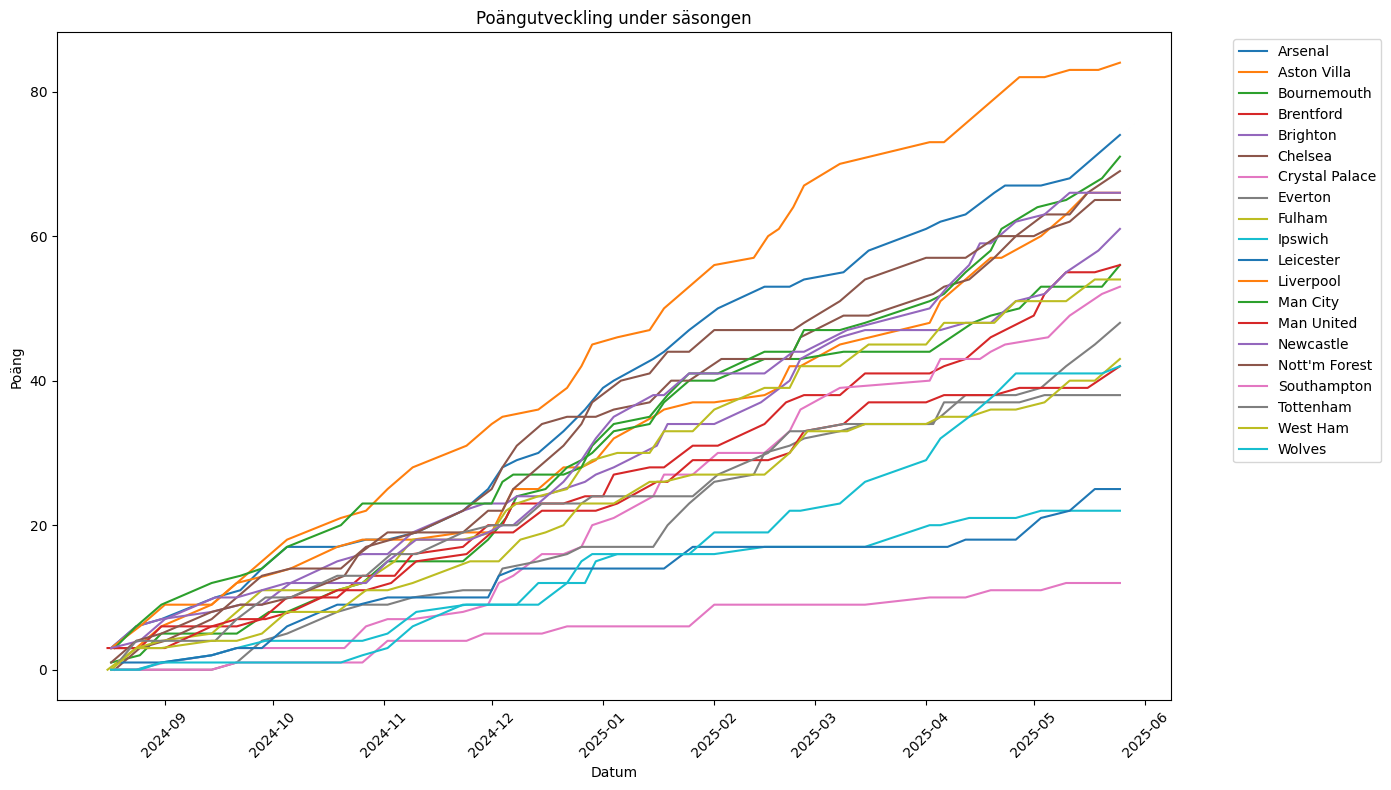

In [59]:
fig, ax = plt.subplots(figsize=(14, 8))

for team, data in all_matches.groupby("Team"):
    data = data.sort_values("Date")
    ax.plot(data["Date"], data["CumPoints"], label=team)

ax.set_xlabel("Datum")
ax.set_ylabel("Poäng")
ax.set_title("Poängutveckling under säsongen")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

### Ser tydligt att Liverpool har hållt ledningen genom största delen av säsongen och Southampton i botten.

In [47]:
home = first_half.groupby("HomeTeam")["HomePoints"].sum() #grupperar Hometeam och Homepoints till en tabell med hemmapoäng.

In [48]:
away = first_half.groupby("AwayTeam")["Awaypoints"].sum() #grupperar Awayteam och Awaypoints till en tabell med bortapoäng.

In [49]:
total_points = home.add(away, fill_value=0) #lägger ihop home och away till total, om inget värde så är det 0.

In [50]:
total_points.sort_values(ascending=False) #sorterar totalpoäng med flest poäng högst upp


HomeTeam
Liverpool         45
Nott'm Forest     37
Arsenal           36
Chelsea           35
Newcastle         32
Man City          31
Bournemouth       30
Fulham            29
Aston Villa       29
Brighton          27
Tottenham         24
Brentford         24
West Ham          23
Man United        22
Crystal Palace    20
Everton           17
Wolves            16
Ipswich           15
Leicester         14
Southampton        6
dtype: int64

# Vilka ligger i toppen av tabellen efter halva säsongen? Något som är oväntat?

Text(0, 0.5, 'Poäng')

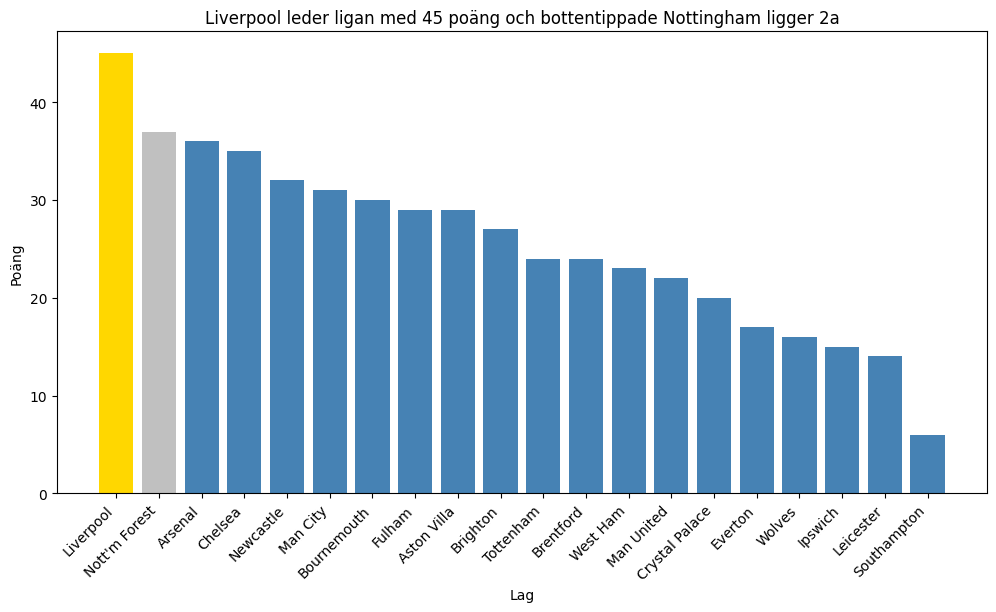

In [51]:
total_points = total_points.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6)) #fig är tavlan och ax är duken
plt.xticks(rotation=45, ha="right")
colors = ["gold" if i == 0 else "silver" if i == 1 else "steelblue" for i in range(len(total_points))]
ax.bar(total_points.index, total_points.values, color=colors)
ax.set_title("Liverpool leder ligan med 45 poäng och bottentippade Nottingham ligger 2a")
ax.set_xlabel("Lag")
ax.set_ylabel("Poäng")

## Liverpool leder ligan efter halva säsongen med 45 poäng. Det mest överraskande är att Nottingham Forest ligger tvåa eftersom dom inte är ett topplag i Premier League.

In [52]:
df["TotalYellow"] = df["HY"] + df["AY"] #slår ihop gulakort per match
df["TotalRed"] = df["HR"] + df["AR"] #slår ihop rödakort per match
yellow_cards = df.groupby("Referee")["TotalYellow"].sum().sort_values(ascending=False) #grupperar Referee och TotalYellow till en tabell med gulakort.
yellow_cards

Referee
S Hooper        108
M Oliver        108
S Barrott       106
C Kavanagh       96
C Pawson         94
R Jones          93
A Taylor         88
A Madley         86
J Brooks         86
P Bankes         85
D England        79
S Attwell        72
T Harrington     72
J Gillett        68
T Robinson       68
D Bond           55
M Salisbury      43
T Bramall        36
D Coote          30
L Smith          26
J Smith          13
S Allison         8
D Webb            7
O Oliver          5
A Kitchen         4
K Kavanagh        3
Name: TotalYellow, dtype: int64

In [53]:
red_cards = df.groupby("Referee")["TotalRed"].sum().sort_values(ascending=False) #grupperar Referee och TotalRed till en tabell med rödkort.
red_cards

Referee
A Taylor        6
M Oliver        5
C Kavanagh      5
T Bramall       4
D England       4
R Jones         4
C Pawson        3
T Harrington    3
S Attwell       3
P Bankes        3
M Salisbury     3
T Robinson      2
S Hooper        2
S Barrott       1
L Smith         1
A Madley        1
J Brooks        1
D Bond          1
O Oliver        0
K Kavanagh      0
J Smith         0
S Allison       0
J Gillett       0
D Webb          0
D Coote         0
A Kitchen       0
Name: TotalRed, dtype: int64

In [54]:
total_cards = yellow_cards.add(red_cards, fill_value=0) #adderar korten
top15 = total_cards.sort_values(ascending=False).head(15) #Tar bara med topp 15
yellow_top15 = yellow_cards[top15.index] 
red_top15 = red_cards[top15.index] #Tar ut olika staplar för röda och gula kort per domare
yellow_top15


Referee
M Oliver        108
S Hooper        108
S Barrott       106
C Kavanagh       96
R Jones          93
C Pawson         94
A Taylor         88
P Bankes         85
A Madley         86
J Brooks         86
D England        79
S Attwell        72
T Harrington     72
T Robinson       68
J Gillett        68
Name: TotalYellow, dtype: int64

# Vilken domare delar ut flest gula kort? (intressant att se röda kort också)

Text(0.5, 1.0, 'M. Oliver toppar listan på gula kort')

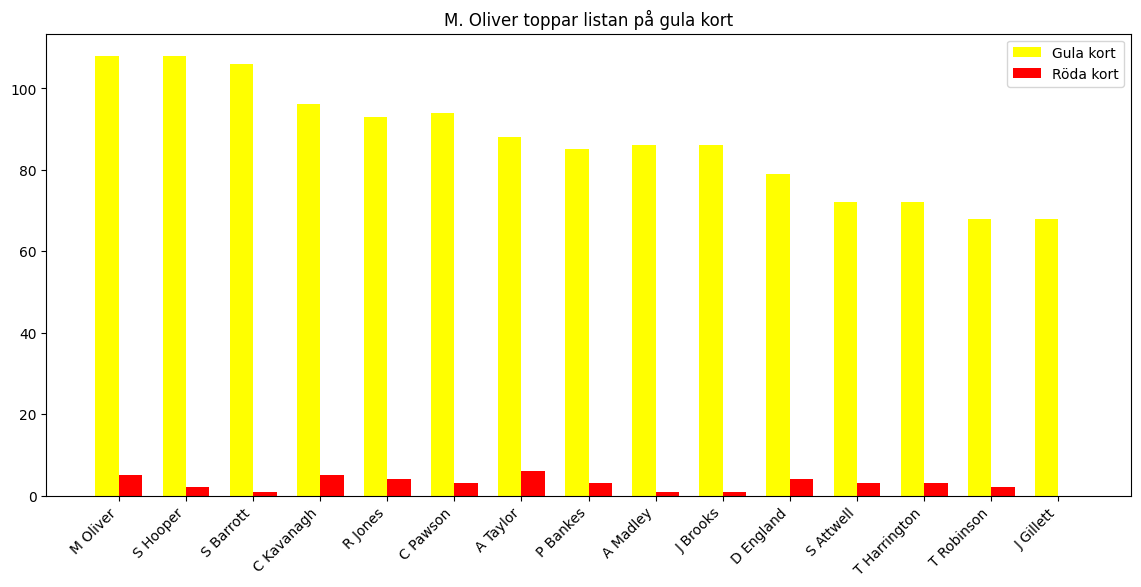

In [55]:
x = np.arange(len(top15.index))  #positioner på x-axeln
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, yellow_top15.values, width, color="yellow", label="Gula kort") #Förskjuter stapeln, gör staplen gul och text som syns i legenden


ax.bar(x + width/2, red_top15.values, width, color="red", label="Röda kort")

ax.set_xticks(x)
ax.set_xticklabels(top15.index, rotation=45, ha="right")
ax.legend()
ax.set_title("M. Oliver toppar listan på gula kort")


## M. Oliver delar ut flest kort bland domarna. Generellt sett delas det ut betydligt fler gula kort än röda. röda kort är relativt sällsynta i Premier League den här säsongen.

In [56]:
home_shots = df.groupby("HomeTeam")["HS"].sum()
away_shots = df.groupby("AwayTeam")["AS"].sum()
total_shots = home_shots.add(away_shots, fill_value=0)
home_wins = df[df["FTR"] == "H"].groupby("HomeTeam")["FTR"].count()
away_wins = df[df["FTR"] == "A"].groupby("AwayTeam")["FTR"].count()
total_wins = home_wins.add(away_wins, fill_value=0)
total_wins.sort_values(ascending=False)

HomeTeam
Liverpool         25
Man City          21
Arsenal           20
Chelsea           20
Newcastle         20
Nott'm Forest     19
Aston Villa       19
Brentford         16
Brighton          16
Bournemouth       15
Fulham            15
Crystal Palace    13
Wolves            12
Man United        11
Everton           11
Tottenham         11
West Ham          11
Leicester          6
Ipswich            4
Southampton        2
Name: FTR, dtype: int64

In [57]:
scatter_df = pd.DataFrame({
    "shots": total_shots,
    "wins": total_wins
}) #skapar en ny DataFrame med kolumnerna shots och wins per lag
scatter_df

,shots,wins
HomeTeam,,
Arsenal,547,20
Aston Villa,484,19
Bournemouth,580,15
Brentford,441,16
Brighton,533,16
Chelsea,595,20
Crystal Palace,516,13
Everton,405,11
Fulham,521,15


# Vinner man fler matcher om man skjuter mycket? Inte om man heter Nottingham

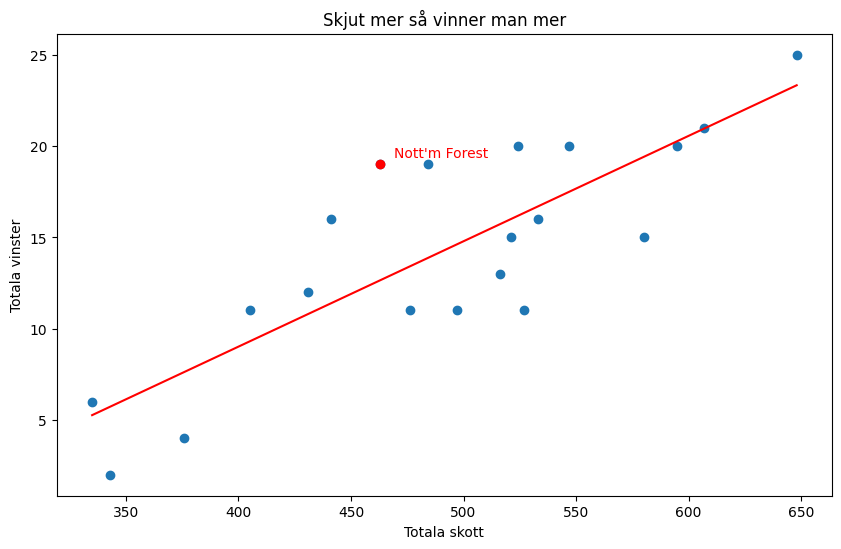

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_df["shots"], scatter_df["wins"])
ax.set_xlabel("Totala skott")
ax.set_ylabel("Totala vinster")
z = np.polyfit(scatter_df["shots"], scatter_df["wins"], 1) #beräknar en "trend" linje
p = np.poly1d(z) 
ax.plot(sorted(scatter_df["shots"]), p(sorted(scatter_df["shots"])), color="red")
ax.set_title("Skjut mer så vinner man mer")
ax.annotate("Nott'm Forest", 
            xy=(scatter_df.loc["Nott'm Forest", "shots"], scatter_df.loc["Nott'm Forest", "wins"]),
            xytext=(10, 5),
            textcoords="offset points",
            color="red")
ax.scatter(scatter_df.loc["Nott'm Forest", "shots"], scatter_df.loc["Nott'm Forest", "wins"], color="red", zorder=5)

## En stark trend att skjuter man mer vinner man fler matcher. Om man inte heter Nottingham då!

# Avslutning.
#### Om ett lag skjuter mycket och brukar det leda till fler vinster och fler poäng. Ser man Liverpool ligger dom högst på vinster, poäng och skott! Såg inga speciella mönster på att om en domare delar ut många gula kort så delar dom ut fler röda. Många obesvarade frågor, Om lag som gör många fouls får fler kort, förlorar mer? Lag som får mycket kort förlorar fler matcher? Datan kan inte berätta vilket lag som håller i bollen mest till exempel. Vilket lag som springer mest. 